# 3. Conditional VAE на мордах

На 3k кропах DCGAN легко схлопывается в пару мод, а автоэнкодер хотя бы обязан восстанавливать вход.

Условие: вид животного (кот/собака). Латент 64, картинка 64×64.


In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import make_grid, save_image
from tqdm.auto import tqdm

import petsdata as P

P.set_seed(P.SEED)
device = P.get_device()
P.CKPT_DIR.mkdir(exist_ok=True)
out_dir = P.RUNS_DIR / "cvae"
out_dir.mkdir(parents=True, exist_ok=True)
print(device)


/Users/mnfom/Projects/cnn-Makarena-211/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mps


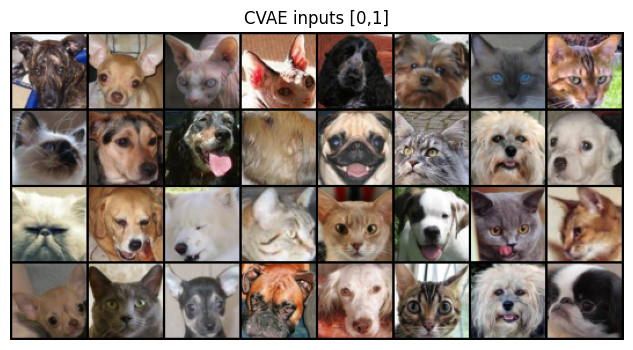

In [2]:
train_df, val_df, test_df, breed2id = P.ensure_splits()
SIZE = 64
BATCH = 64 if device.type != "cpu" else 32
tfms = P.make_tfms(SIZE, imagenet=False, erase=False)
# без erase/affine слишком сильных — VAE и так давит детали
from torchvision import transforms

vae_tfm = transforms.Compose(
    [
        transforms.Resize(SIZE),
        transforms.CenterCrop(SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)
eval_tfm = transforms.Compose(
    [
        transforms.Resize(SIZE),
        transforms.CenterCrop(SIZE),
        transforms.ToTensor(),
    ]
)


class FaceOnly(Dataset):
    def __init__(self, frame, tfm):
        self.frame = frame.reset_index(drop=True)
        self.tfm = tfm

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        from PIL import Image

        row = self.frame.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        return self.tfm(img), int(row["species_id"])


tr = DataLoader(FaceOnly(train_df, vae_tfm), batch_size=BATCH, shuffle=True, drop_last=True)
va = DataLoader(FaceOnly(val_df, eval_tfm), batch_size=BATCH, shuffle=False)

xb, yb = next(iter(tr))
grid = make_grid(xb[:32], nrow=8)
plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("CVAE inputs [0,1]")
plt.show()


In [3]:
Z = 64
N_COND = 2


class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.emb = nn.Embedding(N_COND, 16)
        self.mu = nn.Linear(256 * 4 * 4 + 16, Z)
        self.logv = nn.Linear(256 * 4 * 4 + 16, Z)

    def forward(self, x, y):
        h = self.conv(x).flatten(1)
        h = torch.cat([h, self.emb(y)], 1)
        return self.mu(h), self.logv(h)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(N_COND, 16)
        self.fc = nn.Linear(Z + 16, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid(),
        )

    def forward(self, z, y):
        h = torch.cat([z, self.emb(y)], 1)
        h = self.fc(h).view(-1, 256, 4, 4)
        return self.deconv(h)


class CVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder()
        self.dec = Decoder()

    def reparam(self, mu, logv):
        std = (0.5 * logv).exp()
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, y):
        mu, logv = self.enc(x, y)
        z = self.reparam(mu, logv)
        rec = self.dec(z, y)
        return rec, mu, logv


model = CVAE().to(device)
print("params M", sum(p.numel() for p in model.parameters()) / 1e6)


params M 2.239747


01 rec 0.0744  kl 0.0359  beta 0.25


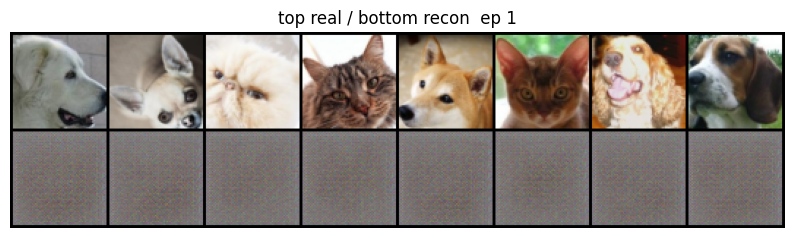

02 rec 0.0630  kl 0.0090  beta 0.50


03 rec 0.0594  kl 0.0104  beta 0.75


04 rec 0.0584  kl 0.0112  beta 1.00


05 rec 0.0585  kl 0.0097  beta 1.25


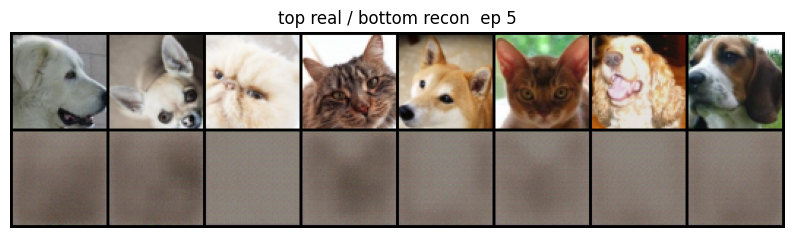

06 rec 0.0588  kl 0.0094  beta 1.50


07 rec 0.0585  kl 0.0091  beta 1.75


08 rec 0.0586  kl 0.0088  beta 2.00


09 rec 0.0580  kl 0.0087  beta 2.00


10 rec 0.0583  kl 0.0087  beta 2.00


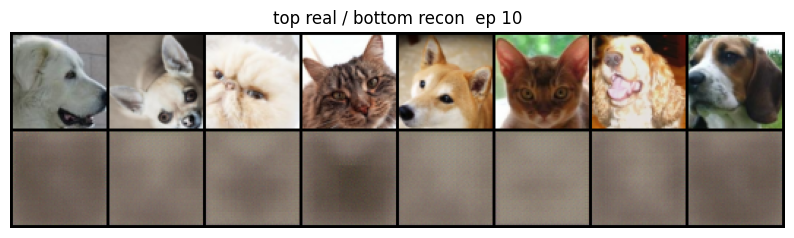

11 rec 0.0587  kl 0.0087  beta 2.00


12 rec 0.0573  kl 0.0085  beta 2.00


13 rec 0.0574  kl 0.0086  beta 2.00


14 rec 0.0576  kl 0.0086  beta 2.00


15 rec 0.0576  kl 0.0086  beta 2.00


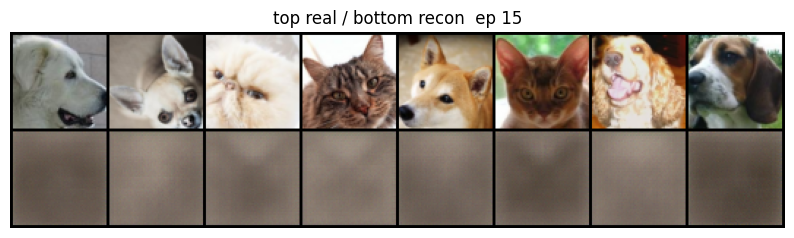

16 rec 0.0570  kl 0.0085  beta 2.00


17 rec 0.0573  kl 0.0086  beta 2.00


18 rec 0.0575  kl 0.0086  beta 2.00


19 rec 0.0574  kl 0.0085  beta 2.00


20 rec 0.0574  kl 0.0085  beta 2.00


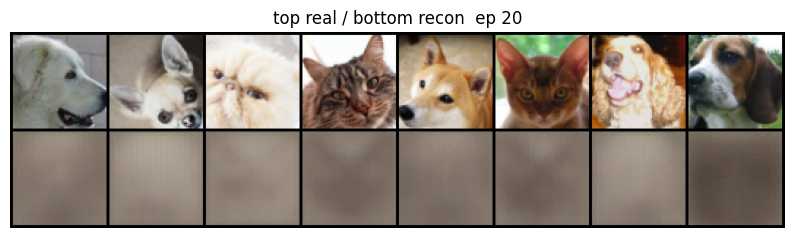

21 rec 0.0572  kl 0.0085  beta 2.00


22 rec 0.0566  kl 0.0085  beta 2.00


23 rec 0.0572  kl 0.0086  beta 2.00


24 rec 0.0569  kl 0.0084  beta 2.00


25 rec 0.0567  kl 0.0085  beta 2.00


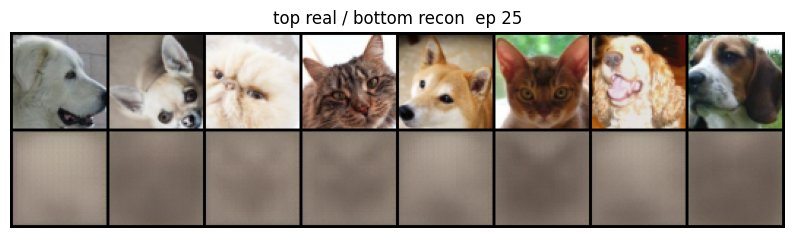

In [4]:
def elbo(x, rec, mu, logv, beta, free_bits=0.5):
    rec_loss = F.mse_loss(rec, x, reduction="mean")
    # per-dim KL, floor so it doesn't die in the first epochs
    kl_dim = -0.5 * (1 + logv - mu.pow(2) - logv.exp())
    kl_dim = torch.clamp(kl_dim, min=free_bits / Z)
    kl = kl_dim.mean()
    return rec_loss + beta * kl, rec_loss, kl


EPOCHS = 25
BETA_MAX = 2.0
opt = torch.optim.Adam(model.parameters(), lr=2e-4)

logs = []
for ep in range(1, EPOCHS + 1):
    model.train()
    beta = BETA_MAX * min(1.0, ep / 8)  # warmup KL
    recs = kls = n = 0.0
    for x, y in tqdm(tr, leave=False, desc=f"ep {ep}"):
        x, y = x.to(device), y.to(device)
        opt.zero_grad(set_to_none=True)
        rec, mu, logv = model(x, y)
        loss, rec_l, kl = elbo(x, rec, mu, logv, beta)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        opt.step()
        bs = x.size(0)
        n += bs
        recs += rec_l.item() * bs
        kls += kl.item() * bs
    model.eval()
    with torch.no_grad():
        vx, vy = next(iter(va))
        vx, vy = vx.to(device), vy.to(device)
        vrec, _, _ = model(vx, vy)
    logs.append({"ep": ep, "rec": recs / n, "kl": kls / n, "beta": beta})
    print(f"{ep:02d} rec {recs/n:.4f}  kl {kls/n:.4f}  beta {beta:.2f}")
    if ep % 5 == 0 or ep == 1:
        show = torch.cat([vx[:8].cpu(), vrec[:8].cpu()], 0)
        g = make_grid(show, nrow=8, padding=2)
        plt.figure(figsize=(10, 3))
        plt.imshow(g.permute(1, 2, 0).clamp(0, 1))
        plt.axis("off")
        plt.title(f"top real / bottom recon  ep {ep}")
        plt.show()
        save_image(g, out_dir / f"recon_{ep:02d}.png")

torch.save({"state": model.state_dict()}, P.CKPT_DIR / "cvae.pt")


Сэмплы из prior при фиксированном условии: верхний ряд коты, нижний собаки.


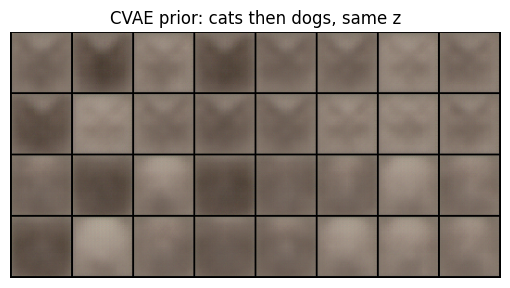

In [5]:
model.eval()
with torch.no_grad():
    z = torch.randn(16, Z, device=device)
    cats = model.dec(z, torch.zeros(16, dtype=torch.long, device=device))
    dogs = model.dec(z, torch.ones(16, dtype=torch.long, device=device))
    g = make_grid(torch.cat([cats, dogs], 0), nrow=8)
plt.figure(figsize=(10, 3.2))
plt.imshow(g.permute(1, 2, 0).cpu().clamp(0, 1))
plt.axis("off")
plt.title("CVAE prior: cats then dogs, same z")
plt.show()
save_image(g, out_dir / "prior_cat_dog.png")


Интерполяция в латенте между двумя валидационными мордами.


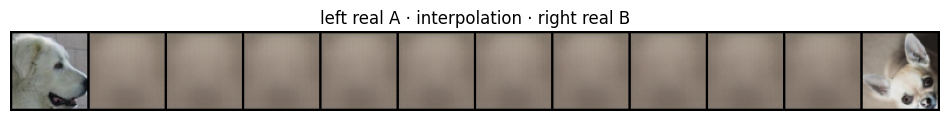

In [6]:
with torch.no_grad():
    x, y = next(iter(va))
    x, y = x.to(device), y.to(device)
    mu, _ = model.enc(x[:2], y[:2])
    ts = torch.linspace(0, 1, 10, device=device)[:, None]
    z = (1 - ts) * mu[0:1] + ts * mu[1:2]
    # condition follows the start image
    rec = model.dec(z, y[0].repeat(10))
    g = make_grid(torch.cat([x[0:1].cpu(), rec.cpu(), x[1:2].cpu()], 0), nrow=12)
plt.figure(figsize=(12, 2))
plt.imshow(g.permute(1, 2, 0).clamp(0, 1))
plt.axis("off")
plt.title("left real A · interpolation · right real B")
plt.show()
save_image(g, out_dir / "interp.png")
